# 05 · Evaluador de incertidumbre y calibración — Etapa ④ del pipeline

**Componente del pipeline:** Uncertainty Evaluator and Probability Calibration (Confidence Scores).

**Entrada:** `data/processed/{train,validacion,test}.csv` + modelo elegido en `resultados/fase3_modelo.json` (04)
**Salida:** `artifacts/modelo_calibrado.pkl` y `resultados/scores_test.csv` (probabilidades calibradas + banda de incertidumbre), que consume `06_decision_accion`.

Método: se entrena el modelo desplegado (Fase 3) en `train`, se calibra por **Platt** (regresión logística sobre el logit) en `validacion`, y se evalúa la calibración en `test`. La incertidumbre epistémica se estima con réplicas bootstrap del entrenamiento.

> El código de modelo/calibración es el mismo de `07_drift_monitoreo` (`construir`, Platt sobre logit); aquí se aísla como etapa propia sobre el split estándar.

In [1]:
import sys; sys.path.append("..")
import json, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logit, expit
from scipy.optimize import minimize_scalar

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import xgboost as xgb

from src.paths import PROCESSED, ARTIFACTS, RESULTADOS

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
SEED = 42
rng = np.random.default_rng(SEED)
MODO_RAPIDO = False                         # True: menos réplicas (para probar)
N_REPLICAS_INCERT = 3 if MODO_RAPIDO else 10
_SK18 = tuple(int(x) for x in sklearn.__version__.split(".")[:2]) >= (1, 8)
print("sklearn", sklearn.__version__, "| xgboost", xgb.__version__)

sklearn 1.6.1 | xgboost 3.2.0


## 1. Carga del dataset preparado (03)

In [2]:
partes = {n: pd.read_csv(PROCESSED / f"{n}.csv") for n in ["train", "validacion", "test"]}
for n, p in partes.items():
    p["y"] = p["target"].astype(int)
    for c in ["max_glu_serum", "A1Cresult"]:
        if c in p.columns:
            p[c] = p[c].fillna("None")
full = pd.concat(partes.values(), ignore_index=True)
print({n: len(p) for n, p in partes.items()}, "| prevalencia <30:", round(full.y.mean(), 4))

{'train': 57709, 'validacion': 17912, 'test': 19830} | prevalencia <30: 0.114


## 2. Definición de variables

In [3]:
USAR_CONTEXTO = False  # ctx_*/rel_* son proxy del periodo (Secc. 10.5 / 03_preprocesamiento); degradan generalizacion -> excluidas
NUM_ESTATICAS = ["age_num", "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
                 "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses_capped",
                 "service_utilization", "n_meds_active", "n_meds_changed", "meds_per_day", "labs_per_day",
                 "n_comorbidity_groups", "dm_primary", "dm_complicated", "a1c_tested", "a1c_high",
                 "glu_tested", "glu_high"]
NUM_TEMPORALES = ["enc_seq", "is_returning", "prev_readmit30", "hist_n_readmit30", "hist_rate_readmit30",
                  "prev_time_in_hospital", "prev_num_medications", "prev_number_diagnoses_capped",
                  "prev_n_meds_active", "delta_num_medications", "delta_n_meds_active",
                  "roll3_time_in_hospital", "log_gap_prev_encounter", "prev_discharge_snf"]
NUM_CONTEXTO = ["ctx_readmit_rate", "ctx_inpatient_mean", "ctx_a1c_rate", "rel_number_diagnoses", "rel_num_medications"]
VARS_CAT = ["gender", "admission_type_grp", "discharge_grp", "admission_source_grp", "specialty_grp",
            "diag_1_grp", "diag_2_grp", "diag_3_grp", "max_glu_serum", "A1Cresult",
            "insulin", "metformin", "glipizide", "glyburide", "pioglitazone", "rosiglitazone",
            "glimepiride", "change", "diabetesMed"]
VARS_NUM = NUM_ESTATICAS + NUM_TEMPORALES + (NUM_CONTEXTO if USAR_CONTEXTO else [])
VARS_CAT = [c for c in VARS_CAT if full[c].nunique() > 1]
FEATURES = VARS_NUM + VARS_CAT   # 'race' NO se incluye (solo auditoría de equidad)
X = {n: partes[n][FEATURES] for n in partes}
Y = {n: partes[n]["y"] for n in partes}
print(f"{len(VARS_NUM)} numéricas + {len(VARS_CAT)} categóricas = {len(FEATURES)} variables")

35 numéricas + 19 categóricas = 54 variables

## 3. Métricas de calibración

In [4]:
def logistica_sin_penalizacion():
    return LogisticRegression(C=np.inf, max_iter=1000) if _SK18 else LogisticRegression(penalty=None, max_iter=1000)

def pendiente_intercepto(y, p):
    lp = logit(np.clip(p, 1e-6, 1 - 1e-6))
    pendiente = logistica_sin_penalizacion().fit(lp.reshape(-1, 1), y).coef_[0, 0]
    def nll(a):
        q = np.clip(expit(a + lp), 1e-9, 1 - 1e-9)
        return -np.sum(y * np.log(q) + (1 - y) * np.log(1 - q))
    intercepto = minimize_scalar(nll, bounds=(-5, 5), method="bounded").x
    return pendiente, intercepto

def ece(y, p, bins=10):
    grupos = pd.qcut(p, bins, labels=False, duplicates="drop")
    d = pd.DataFrame({"y": y, "p": p, "g": grupos}).groupby("g").agg(y=("y", "mean"), p=("p", "mean"), n=("y", "size"))
    return float(np.sum(d.n * (d.y - d.p).abs()) / d.n.sum())

def metricas(y, p):
    y = np.asarray(y); p = np.asarray(p); prev = y.mean()
    pend, inter = pendiente_intercepto(y, p); brier = brier_score_loss(y, p)
    return {"n": len(y), "prevalencia": prev, "ROC_AUC": roc_auc_score(y, p),
            "PR_AUC": average_precision_score(y, p), "lift_PR": average_precision_score(y, p) / prev,
            "Brier": brier, "BSS": 1 - brier / (prev * (1 - prev)),
            "pendiente_cal": pend, "intercepto_cal": inter, "ECE": ece(y, p)}

## 4. Modelo desplegado y calibración de Platt (train → validación)

In [5]:
def construir(nombre, params):
    if nombre == "ElasticNet":
        pre = ColumnTransformer([
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), VARS_NUM),
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30), VARS_CAT)])
        kw = dict(solver="saga", max_iter=300, tol=1e-3, random_state=SEED, **params)
        if not _SK18: kw["penalty"] = "elasticnet"
        clf = LogisticRegression(**kw)
    elif nombre == "RandomForest":
        pre = ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), VARS_NUM),
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30), VARS_CAT)])
        clf = RandomForestClassifier(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=SEED, **params)
    elif nombre == "XGBoost":
        pre = ColumnTransformer([
            ("num", "passthrough", VARS_NUM),
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30), VARS_CAT)])
        clf = xgb.XGBClassifier(learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                                min_child_weight=5, reg_lambda=1.0, tree_method="hist",
                                eval_metric="logloss", n_jobs=-1, random_state=SEED, **params)
    else:
        raise ValueError(nombre)
    return Pipeline([("pre", pre), ("clf", clf)])

def ajustar_pipeline(nombre, params, Xdf, y, semilla=None):
    pipe = construir(nombre, params)
    if semilla is not None:
        pipe.set_params(clf__random_state=semilla)
    pipe.fit(Xdf, y)
    return pipe

In [6]:
with open(RESULTADOS / "fase3_modelo.json") as f:
    fase3 = json.load(f)
MODELO_PRINCIPAL = fase3["modelo_principal"]
PARAMS = fase3["mejores"][MODELO_PRINCIPAL]
print("Modelo desplegado (Fase 3):", MODELO_PRINCIPAL, "| hiperparámetros:", PARAMS)

def _logit_clip(s):
    return logit(np.clip(s, 1e-6, 1 - 1e-6)).reshape(-1, 1)

# Entrenar en train, calibrar (Platt) en validación
pipe = ajustar_pipeline(MODELO_PRINCIPAL, PARAMS, X["train"], Y["train"])
cal = logistica_sin_penalizacion().fit(_logit_clip(pipe.predict_proba(X["validacion"])[:, 1]), Y["validacion"])

def prob_raw(Xdf):
    return pipe.predict_proba(Xdf)[:, 1]
def prob_cal(Xdf):
    return cal.predict_proba(_logit_clip(prob_raw(Xdf)))[:, 1]

p_raw = prob_raw(X["test"]); p_cal = prob_cal(X["test"])
print("test: p_raw medio =", round(p_raw.mean(), 4), "| p_cal medio =", round(p_cal.mean(), 4),
      "| prevalencia =", round(Y["test"].mean(), 4))

Modelo desplegado (Fase 3): RandomForest | hiperparámetros: {'max_depth': 14, 'min_samples_leaf': 20}


test: p_raw medio = 0.1291 | p_cal medio = 0.1084 | prevalencia = 0.1087


## 5. Evaluación de la calibración (sin calibrar vs Platt)

,n,prevalencia,ROC_AUC,PR_AUC,lift_PR,Brier,BSS,pendiente_cal,intercepto_cal,ECE
sin calibrar,19830.0,0.1087,0.6854,0.2268,2.0868,0.0924,0.0458,1.3624,-0.2015,0.0212
calibrado (Platt),19830.0,0.1087,0.6854,0.2268,2.0868,0.0919,0.0508,1.1657,0.0031,0.0086


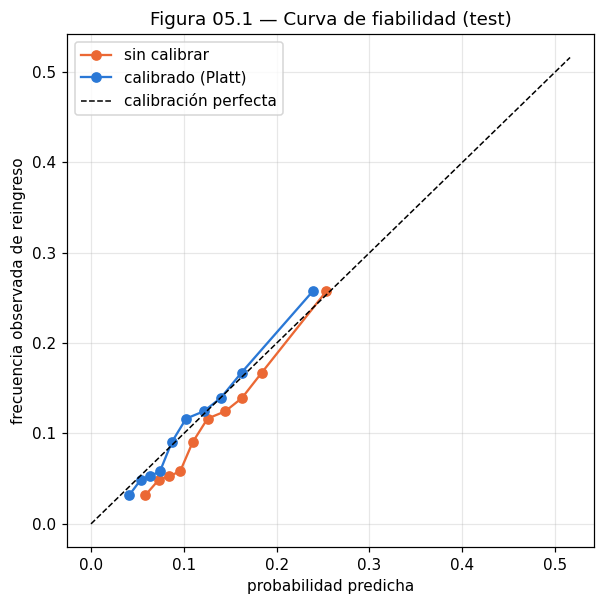

In [7]:
comp = pd.DataFrame({"sin calibrar": metricas(Y["test"], p_raw),
                     "calibrado (Platt)": metricas(Y["test"], p_cal)}).T
display(comp.round(4))

fig, ax = plt.subplots(figsize=(5.6, 5.6))
for p, lab, col in [(p_raw, "sin calibrar", "#eb6834"), (p_cal, "calibrado (Platt)", "#2a78d6")]:
    g = pd.qcut(p, 10, duplicates="drop")
    dd = pd.DataFrame({"y": Y["test"].values, "p": p, "g": g}).groupby("g", observed=True).agg(
        obs=("y", "mean"), pred=("p", "mean"))
    ax.plot(dd.pred, dd.obs, "o-", color=col, label=lab)
lim = float(max(p_raw.max(), p_cal.max()))
ax.plot([0, lim], [0, lim], "k--", lw=1, label="calibración perfecta")
ax.set_xlabel("probabilidad predicha"); ax.set_ylabel("frecuencia observada de reingreso")
ax.set_title("Figura 05.1 — Curva de fiabilidad (test)"); ax.legend()
plt.tight_layout(); plt.savefig(RESULTADOS / "05_calibracion.png", bbox_inches="tight"); plt.show()

## 6. Incertidumbre epistémica (réplicas bootstrap)

In [8]:
# Banda 5–95 % por paciente: se reentrena el modelo en réplicas bootstrap de train y se recalibra en validación
R = []
for i in range(N_REPLICAS_INCERT):
    idx = np.random.default_rng(i).integers(0, len(X["train"]), len(X["train"]))
    pi = ajustar_pipeline(MODELO_PRINCIPAL, PARAMS, X["train"].iloc[idx], Y["train"].iloc[idx], semilla=i)
    ci = logistica_sin_penalizacion().fit(_logit_clip(pi.predict_proba(X["validacion"])[:, 1]), Y["validacion"])
    R.append(ci.predict_proba(_logit_clip(pi.predict_proba(X["test"])[:, 1]))[:, 1])
R = np.column_stack(R)
lo, hi = np.percentile(R, 5, axis=1), np.percentile(R, 95, axis=1)
p_std = R.std(axis=1)
print(f"Réplicas: {N_REPLICAS_INCERT} | ancho medio banda 5–95%: {(hi - lo).mean():.3f} | std media: {p_std.mean():.3f}")

Réplicas: 10 | ancho medio banda 5–95%: 0.030 | std media: 0.011


## 7. Exportación (modelo calibrado + scores de test)

In [9]:
ARTIFACTS.mkdir(parents=True, exist_ok=True); RESULTADOS.mkdir(parents=True, exist_ok=True)
with open(ARTIFACTS / "modelo_calibrado.pkl", "wb") as f:
    pickle.dump({"pipe": pipe, "cal": cal, "modelo": MODELO_PRINCIPAL, "params": PARAMS,
                 "FEATURES": FEATURES, "VARS_NUM": VARS_NUM, "VARS_CAT": VARS_CAT}, f)

scores = partes["test"][["encounter_id", "patient_nbr", "period", "age_num", "gender"]].copy()
scores["y_true"] = Y["test"].values
scores["p_raw"] = p_raw
scores["p_cal"] = p_cal
scores["p_lo"] = lo
scores["p_hi"] = hi
scores["p_std"] = p_std
scores.to_csv(RESULTADOS / "scores_test.csv", index=False)
print("Guardado -> artifacts/modelo_calibrado.pkl | resultados/scores_test.csv", scores.shape)
scores.head()

Guardado -> artifacts/modelo_calibrado.pkl | resultados/scores_test.csv (19830, 11)


,encounter_id,patient_nbr,period,age_num,gender,y_true,p_raw,p_cal,p_lo,p_hi,p_std
0,252314172,32776020,16,95,Female,0,0.113604,0.090865,0.076086,0.102309,0.009836
1,252317628,86487750,16,55,Female,0,0.047977,0.032466,0.023642,0.036903,0.004491
2,252321612,109403766,16,75,Female,0,0.087113,0.066112,0.059810,0.076501,0.005558
3,252327498,35998668,16,65,Male,0,0.063569,0.045382,0.040703,0.049335,0.003327
4,252329064,87987879,16,55,Female,0,0.127391,0.104250,0.104828,0.126242,0.007605
